### <b><font color='saddlebrown'>сследовательский анализ данных</font></b>

##### <b><font color='saddlebrown'>Описание датасета used_cars_data</font></b>

- <i>Name</i>: Марка и модель автомобиля
- <i>Location</i>: Город, в котором автомобиль продается
- <i>Year</i>: Год выпуска
- <i>Kilometers_Driven</i>: Пробег (в км)
- <i>Fuel_Type</i>: Тип топлива, используемого автомобилем
- <i>Transmission</i>: Тип коробки передач
- <i>Owner_Type</i>: Количество предыдущих владельцев
- <i>Mileage</i>: Расход топлива (в км/л или км/кг)
- <i>Engine</i>: Объем двигателя (в см³)
- <i>Power</i>: Максимальная мощность двигателя (в л.с.)
- <i>Seats</i>: Количество мест в автомобиле
- <i>New_Price</i>: Стоимость нового автомобиля той же марки
- <i>Price</i>: Цена подержанного автомобиля (в лакхах)<br>

Цель - на основе этих данных построить модель для прогнозирования цен подержанных автомобилей.

In [39]:
# мпорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### <b><font color='saddlebrown'>Этап 1 - Загрузка и первоначальная проверка данных</font></b>

In [40]:
# Загрузите датасет used_cars_data.csv в датафрейм df_cars
df_cars = pd.read_csv('../data/used_cars_data.csv')
df_cars.head(5)

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [41]:
# Получите общее представление о данных
df_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 793.4+ KB


In [42]:
# Выведите количество отсутствующих значений в каждом столбце
df_cars.isnull().sum()

S.No.                   0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234
dtype: int64

In [43]:
# Посмотрите кол-во уникальных значений в каждом столбце
#  на основе данной информации сделайте вывод о категориальных и непрерывных столбцах
df_cars.nunique()

S.No.                7253
Name                 2041
Location               11
Year                   23
Kilometers_Driven    3660
Fuel_Type               5
Transmission            2
Owner_Type              4
Mileage               450
Engine                150
Power                 386
Seats                   9
New_Price             625
Price                1373
dtype: int64

In [44]:
# Проверьте, есть ли дубликаты строк в датасете
df_cars[df_cars.duplicated()]

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price


##### <b><font color='saddlebrown'>Этап 2 - Преобразование данных</font></b>
Сокращение, исключение, корректировка, дополнение

In [45]:
# сключите столбец S.No так как он не несет в себе смысловую нагрузку для нашей задачи
df_cars = df_cars.drop(['S.No.'], axis = 1)

In [46]:
# Создайте новый столбец car_age, в котором рассчитайте возраст автомобиля
from datetime import date
date.today().year
df_cars['Car_Age'] = date.today().year - df_cars['Year']
df_cars.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,16
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,11
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,15
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,14
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,13


In [47]:
# На основании столбца Name создайте 2 столбца: Brand и Model
df_cars['Brand'] = df_cars.Name.str.split().str.get(0)
df_cars['Model'] = df_cars.Name.str.split().str.get(1) + df_cars.Name.str.split().str.get(2)
df_cars.sample(10)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age,Brand,Model
4574,Hyundai Creta 1.6 CRDi SX Option,Bangalore,2016,51000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,13.25,10,Hyundai,Creta1.6
3050,Tata Indica Vista Aqua 1.3 Quadrajet,Jaipur,2009,117000,Diesel,Manual,First,18.0 kmpl,1248 CC,75 bhp,5.0,NaN,1.10,17,Tata,IndicaVista
5179,Audi A4 2.0 TDI,Hyderabad,2011,54000,Diesel,Automatic,First,16.55 kmpl,1968 CC,147.51 bhp,5.0,NaN,18.00,15,Audi,A42.0
5988,Renault Duster 85PS Diesel RxL Option,Mumbai,2013,102486,Diesel,Manual,First,19.87 kmpl,1461 CC,83.8 bhp,5.0,NaN,4.25,13,Renault,Duster85PS
3052,Hyundai Xcent 1.2 CRDi S,Mumbai,2016,50000,Diesel,Manual,First,25.4 kmpl,1186 CC,73.97 bhp,5.0,8.84 Lakh,3.50,10,Hyundai,Xcent1.2
2475,Honda Mobilio RS i DTEC,Delhi,2015,31250,Diesel,Manual,First,24.5 kmpl,1498 CC,98.6 bhp,7.0,NaN,6.50,11,Honda,MobilioRS
4801,Land Rover Freelander 2 SE,Hyderabad,2011,68000,Diesel,Automatic,First,12.39 kmpl,2179 CC,147.51 bhp,5.0,NaN,22.00,15,Land,RoverFreelander
2493,Mercedes-Benz New C-Class C 220d Avantgarde Ed...,Bangalore,2017,20149,Diesel,Automatic,First,19.27 kmpl,2143 CC,167.62 bhp,5.0,NaN,38.50,9,Mercedes-Benz,NewC-Class
3966,Mahindra XUV500 W8 2WD,Mumbai,2016,120000,Diesel,Manual,First,15.1 kmpl,2179 CC,140 bhp,7.0,NaN,12.00,10,Mahindra,XUV500W8
3502,Hyundai i20 Asta 1.4 CRDi,Pune,2015,54339,Diesel,Manual,Second,22.54 kmpl,1396 CC,88.73 bhp,5.0,NaN,6.00,11,Hyundai,i20Asta


In [48]:
# Выведите список уникальных значений в столбце Brand
df_cars.Brand.unique()

array(['Maruti', 'Hyundai', 'Honda', 'Audi', 'Nissan', 'Toyota',
       'Volkswagen', 'Tata', 'Land', 'Mitsubishi', 'Renault',
       'Mercedes-Benz', 'BMW', 'Mahindra', 'Ford', 'Porsche', 'Datsun',
       'Jaguar', 'Volvo', 'Chevrolet', 'Skoda', 'Mini', 'Fiat', 'Jeep',
       'Smart', 'Ambassador', 'Isuzu', 'ISUZU', 'Force', 'Bentley',
       'Lamborghini', 'Hindustan', 'OpelCorsa'], dtype=object)

In [49]:
# Замените некорректные названия брендов на правильные 
df_cars["Brand"] = df_cars["Brand"].replace({"ISUZU": "Isuzu", "Mini": "Mini Cooper","Land":"Land Rover"})

In [50]:
# Удалите столбец Name
del df_cars['Name']

In [51]:
# Выделите из столбцов Mileage, Engine и Power, New_Price числовую часть и единицу измерения
# Назовите новые столбцы Mileage_num, Mileage_units, Engine_num, Engine_units
# Power_num, Power_units, New_Price_num, New_Price_units
for i in ['Mileage', 'Engine', 'Power', 'New_Price']:
    df_cars[f'{i}_num'] = df_cars[i].str.split().str.get(0)
    df_cars.replace(['null', 'None', '', 'NaN', 'nan'], np.nan, inplace=True)
    df_cars[f'{i}_units'] = df_cars[i].str.split().str.get(1)
    df_cars[f'{i}_num'] = df_cars[f'{i}_num'].astype(float)
df_cars.sample(10)

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
2599,Bangalore,2014,60000,Diesel,Manual,Second,13.49 kmpl,2179 CC,138.03 bhp,5.0,...,Tata,XenonXT,13.49,kmpl,2179.0,CC,138.03,bhp,NaN,NaN
2140,Chennai,2017,80000,Diesel,Manual,First,24.52 kmpl,1248 CC,88.5 bhp,7.0,...,Maruti,ErtigaSHVS,24.52,kmpl,1248.0,CC,88.50,bhp,NaN,NaN
3705,Coimbatore,2019,29311,Diesel,Automatic,First,17.9 kmpl,2143 CC,170 bhp,5.0,...,Mercedes-Benz,GLC220d,17.90,kmpl,2143.0,CC,170.00,bhp,64.57,Lakh
3988,Ahmedabad,2013,31000,Diesel,Manual,First,25.0 kmpl,1396 CC,69.01 bhp,5.0,...,Tata,IndigoeCS,25.00,kmpl,1396.0,CC,69.01,bhp,NaN,NaN
2610,Kochi,2016,38735,Petrol,Manual,First,19.4 kmpl,1198 CC,86.8 bhp,5.0,...,Honda,BrioS,19.40,kmpl,1198.0,CC,86.80,bhp,NaN,NaN
6756,Hyderabad,2016,90000,Diesel,Manual,First,19.3 kmpl,1248 CC,73.9 bhp,5.0,...,Maruti,SwiftDzire,19.30,kmpl,1248.0,CC,73.90,bhp,NaN,NaN
2391,Kochi,2016,51950,Petrol,Manual,First,20.73 kmpl,1373 CC,91.1 bhp,5.0,...,Maruti,CiazVXi,20.73,kmpl,1373.0,CC,91.10,bhp,NaN,NaN
4818,Coimbatore,2015,84931,Diesel,Manual,First,15.3 kmpl,2956 CC,83.8 bhp,7.0,...,Tata,SumoEX,15.30,kmpl,2956.0,CC,83.80,bhp,NaN,NaN
550,Kochi,2009,69690,Petrol,Manual,First,17.7 kmpl,1497 CC,78 bhp,5.0,...,Honda,CityZX,17.70,kmpl,1497.0,CC,78.00,bhp,NaN,NaN
2628,Bangalore,2011,61000,Petrol,Manual,Second,16.2 kmpl,1599 CC,103.2 bhp,5.0,...,Hyundai,VernaTransform,16.20,kmpl,1599.0,CC,103.20,bhp,NaN,NaN


In [52]:
# зучите уникальные значения единиц измерения в новых столбцах
print(df_cars.Mileage_units.unique())
print(df_cars.Engine_units.unique())
print(df_cars.Power_units.unique())
print(df_cars.New_Price_units.unique())

['km/kg' 'kmpl' nan]
['CC' nan]
['bhp' nan]
[nan 'Lakh' 'Cr']


In [53]:
# Там, где это необходимо, переведите числовые значения в единые единицы измерения
# 1 km/kg=1.333 kmpl
# 1 Cr = 100 Lakh
df_cars.loc[df_cars['Mileage_units'] =='km/kg', 'Mileage_num'] *= 1.333
df_cars.loc[df_cars['Mileage_units'] =='km/kg', 'Mileage_units'] = 'kmpl'

In [54]:
df_cars.loc[df_cars['New_Price_units'] =='Cr', 'New_Price_num'] *= 100
df_cars.loc[df_cars['New_Price_units'] =='Cr', 'New_Price_units'] = 'Lakh'

In [55]:
# Переведите столбец Seats в целочисленный тип при возможности
df_cars['Seats'].unique()

array([ 5.,  7.,  8.,  4.,  6.,  2., nan, 10.,  9.,  0.])

In [56]:
# В столбце Mileage_num есть значение 0 - это похоже на ошибку ввода данных
# Замените 0 на NaN
df_cars.loc[df_cars["Mileage_num"] == 0.0,'Mileage_num'] = np.nan
df_cars.Mileage_num.isnull().sum()

np.int64(83)

In [57]:
# Заполните отсутствующие значения в столбце Mileage_num средним арифметическим
df_cars['Mileage_num'] = df_cars['Mileage_num'].fillna(value = np.mean(df_cars['Mileage_num']))

In [58]:
# В столбце Seats также есть значение 0 - это похоже на ошибку ввода данных
# Замените 0 на NaN
df_cars.loc[df_cars["Seats"] == 0.0,'Seats'] = np.nan
df_cars.Seats.isnull().sum()

np.int64(54)

In [59]:
# Заполните отсутствующие значения в столбце Seats медианным значением для данных автомобилей
median_values = df_cars.groupby(['Model', 'Brand'])['Seats'].transform('median')
df_cars.loc[df_cars['Seats'].isnull(), 'Seats'] = df_cars['Seats'].fillna(median_values)

In [60]:
# Заполните пропуски в столбцах Engine_num и Power_num средними значениями для данных моделей.
median_values = df_cars.groupby(['Model', 'Brand'])['Engine_num'].transform('median')
df_cars.loc[df_cars['Engine_num'].isnull(), 'Engine_num'] = df_cars['Engine_num'].fillna(median_values)
mean_values = df_cars.groupby(['Model', 'Brand'])['Power_num'].transform('mean')
df_cars.loc[df_cars['Power_num'].isnull(), 'Power_num'] = df_cars['Power_num'].fillna(mean_values)

In [61]:
# Проверьте, остались ли еще пропущенные значения
# Подумайте, что можно с ними сделать
df_cars[df_cars['Engine_num'].isnull() == True]

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
208,Kolkata,2010,42001,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,...,Maruti,Swift1.3,16.1,kmpl,NaN,NaN,NaN,NaN,NaN,NaN
733,Chennai,2006,97800,Petrol,Manual,Third,16.1 kmpl,NaN,NaN,NaN,...,Maruti,Swift1.3,16.1,kmpl,NaN,NaN,NaN,NaN,NaN,NaN
1327,Hyderabad,2015,50295,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,...,Maruti,Swift1.3,16.1,kmpl,NaN,NaN,NaN,NaN,NaN,NaN
2074,Pune,2011,24255,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,...,Maruti,Swift1.3,16.1,kmpl,NaN,NaN,NaN,NaN,NaN,NaN
2325,Pune,2015,67000,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,...,Maruti,Swift1.3,16.1,kmpl,NaN,NaN,NaN,NaN,NaN,NaN
2335,Mumbai,2007,55000,Petrol,Manual,Second,16.1 kmpl,NaN,NaN,NaN,...,Maruti,Swift1.3,16.1,kmpl,NaN,NaN,NaN,NaN,NaN,NaN
2668,Kolkata,2014,32986,Petrol,Manual,First,16.1 kmpl,NaN,NaN,NaN,...,Maruti,Swift1.3,16.1,kmpl,NaN,NaN,NaN,NaN,NaN,NaN
3404,Jaipur,2006,125000,Petrol,Manual,Fourth & Above,16.1 kmpl,NaN,NaN,NaN,...,Maruti,Swift1.3,16.1,kmpl,NaN,NaN,NaN,NaN,NaN,NaN
3810,Kolkata,2013,27000,Petrol,Automatic,First,14.0 kmpl,NaN,NaN,NaN,...,Honda,CR-VAT,14.0,kmpl,NaN,NaN,NaN,NaN,NaN,NaN
4011,Pune,2011,45271,Diesel,Manual,First,20.3 kmpl,NaN,NaN,NaN,...,Fiat,Punto1.3,20.3,kmpl,NaN,NaN,NaN,NaN,NaN,NaN


##### <b><font color='saddlebrown'>Этап 3 - Основной</font></b>
- проверка выбросов, закономерностей и тенденций в данных
- нахождение значимых закономерностей в данных
- получение  углубленной информации о наборах данных для решения наших бизнес-задач
- определение принципа заполнения пропущенных значений в наборе данных.

###### <b><font color='saddlebrown'>3.1. Вывод описательных статистик</font></b>

In [62]:
# Выведите описательные статистики для всех столбцов и проанализируйте полученную инфомрацию


###### <b><font color='saddlebrown'>3.2. Одномерный анализ.</font></b>
На этом этапе мы должны изучить распределение данных в каждом столбце в отдельности.

In [63]:
# Разделите на 2 списка категориальные (cat_cols) и числовые (num_cols) столбцы 
# спользуйте функцию select_dtypes c параметром
# - include = ['object'] для категориальных данных
# - include = np.number для числовых данных
cat_cols=df_cars.select_dtypes(include=['object']).columns.tolist()

In [64]:
# Визуализируйте числовые переменные с помощью гистограмм и боксплотов


In [65]:
# Визуализируйте категориальные переменные с помощью столбчатых диаграмм


In [66]:
# Переменные Price и Kilometers_Driven сильно асимметричны. 
# В таких случаях может помочь логарифмическое преобразование – оно нормализует данные, стандартизирует распределение переменных.


###### <b><font color='saddlebrown'>3.3. Двумерный анализ</font></b>
Двумерный анализ помогает понять, как независимые переменные связаны друг с другом, а также как независимые переменные влияют на зависимые. Для числовых столбцов  двумерный анализ выполняется с помощью парных графиков и диаграмм рассеяния. Для категориальных переменных используются столбчатые диаграммы разных типов.

Числовые столбцы для pairplot: ['Car_Age', 'Engine_num', 'Kilometers_Driven', 'Mileage_num', 'New_Price_num', 'Power_num', 'Price', 'Seats', 'Year']


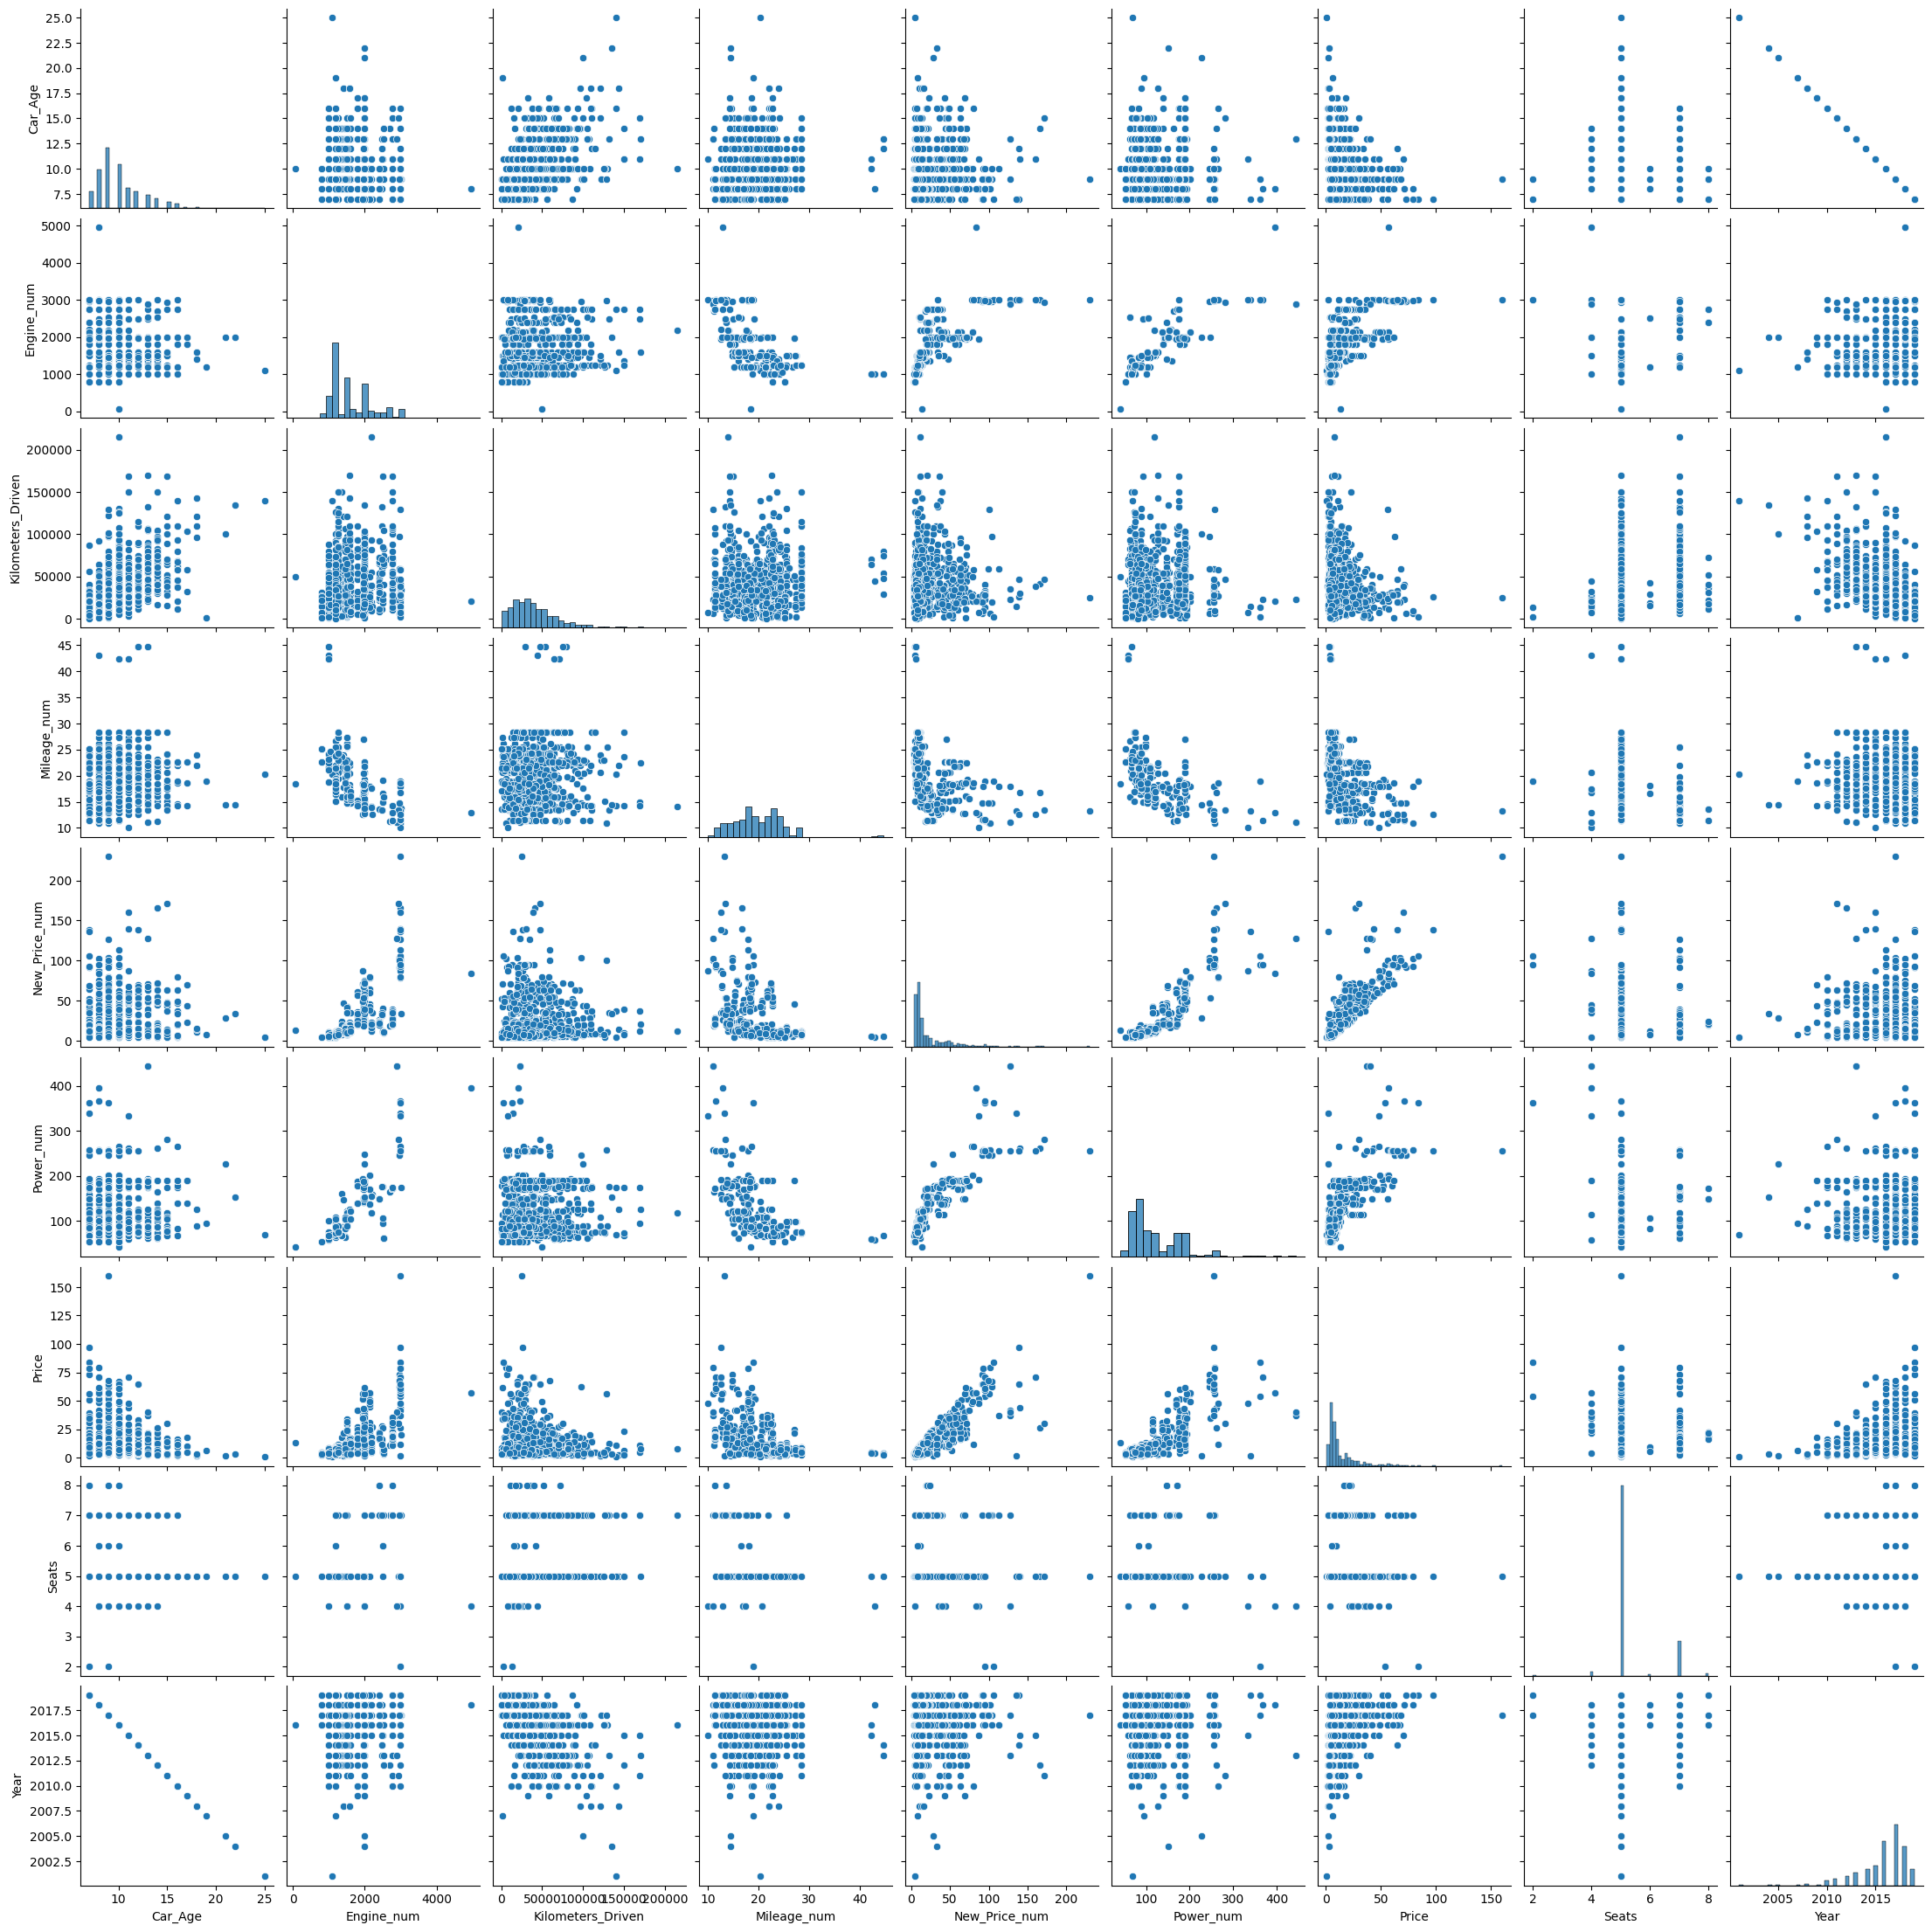

In [67]:
# Постройте парный график для всех числовых столбцов нашего набора данных
# Собираем все числовые столбцы + столбцы с суффиксом _num
num_cols = df_cars.select_dtypes(include=np.number).columns.tolist()
num_suffix_cols = [c for c in df_cars.columns if c.endswith('_num')]
num_cols = sorted(set(num_cols + num_suffix_cols))

print('Числовые столбцы для pairplot:', num_cols)
sns.pairplot(df_cars[num_cols].dropna())
plt.show()

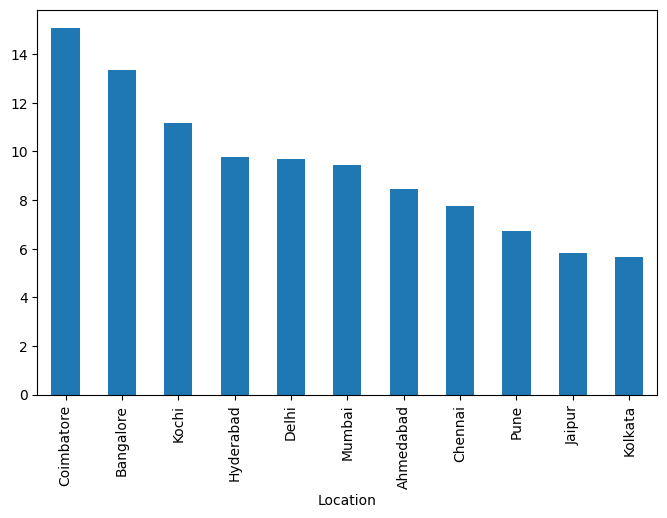

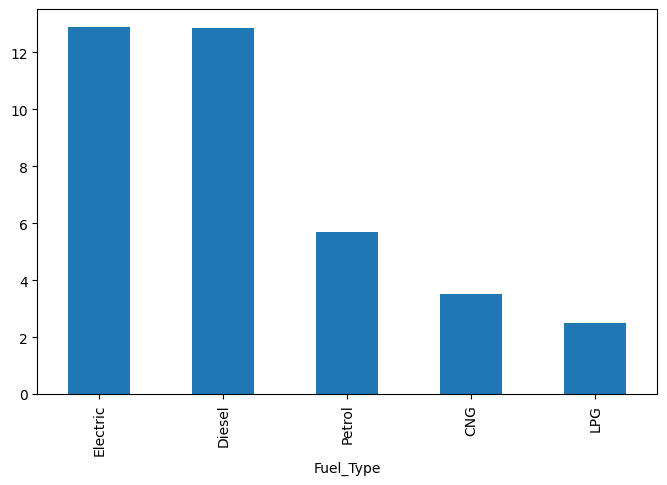

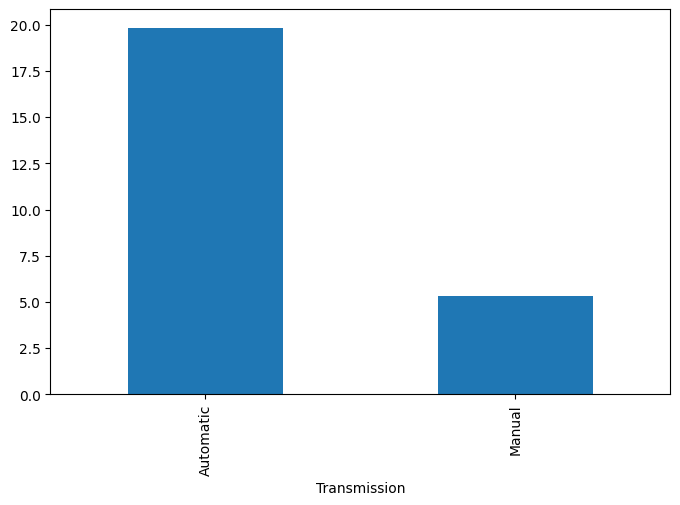

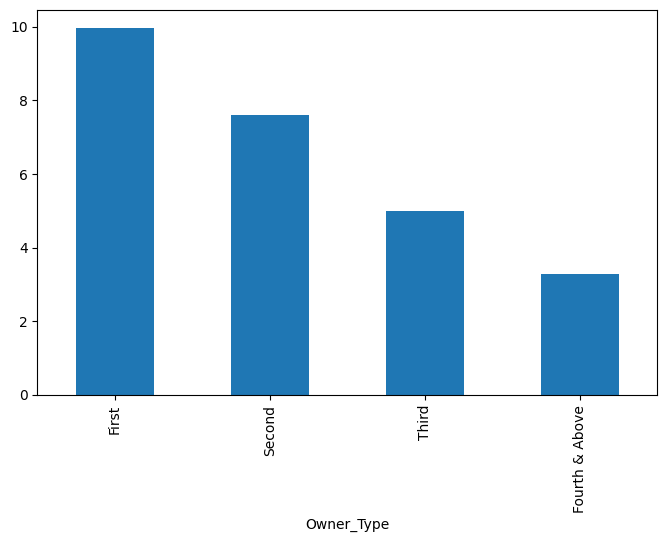

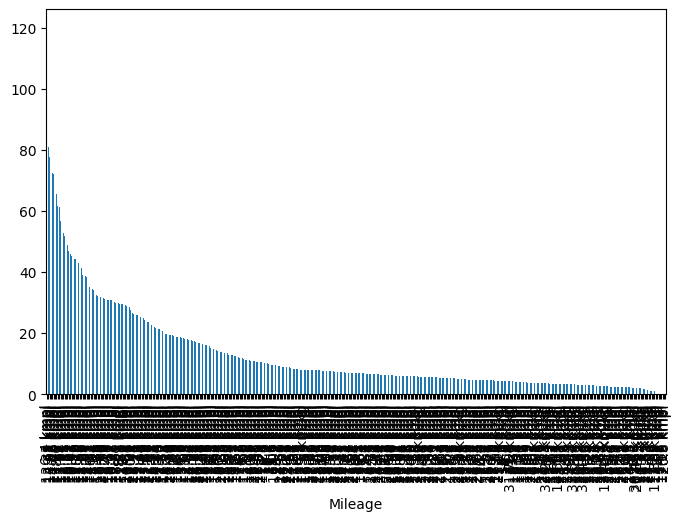

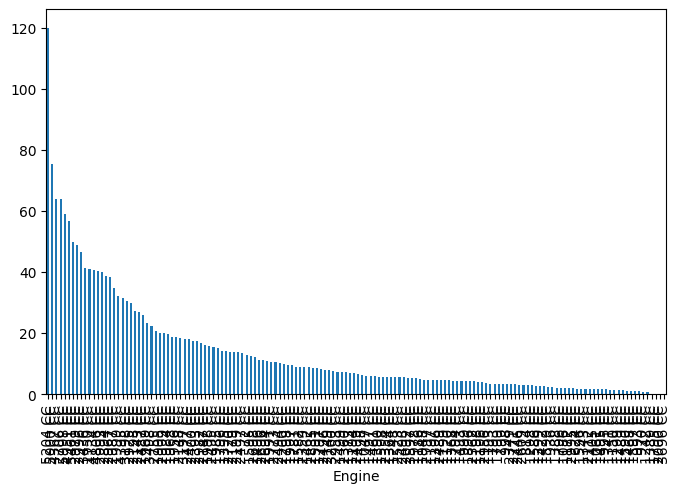

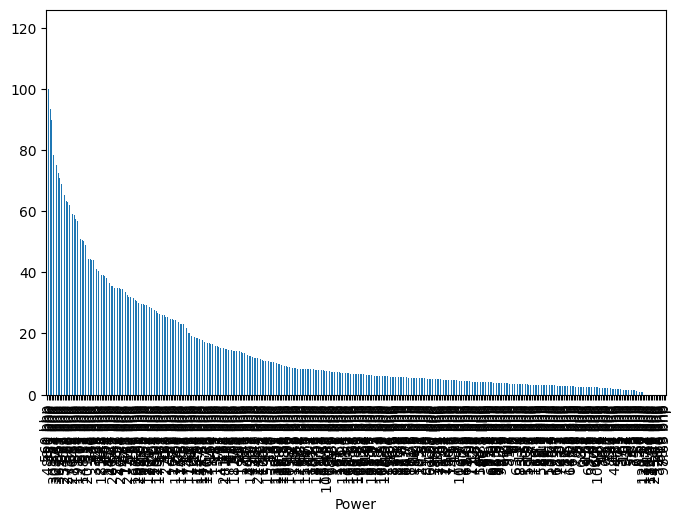

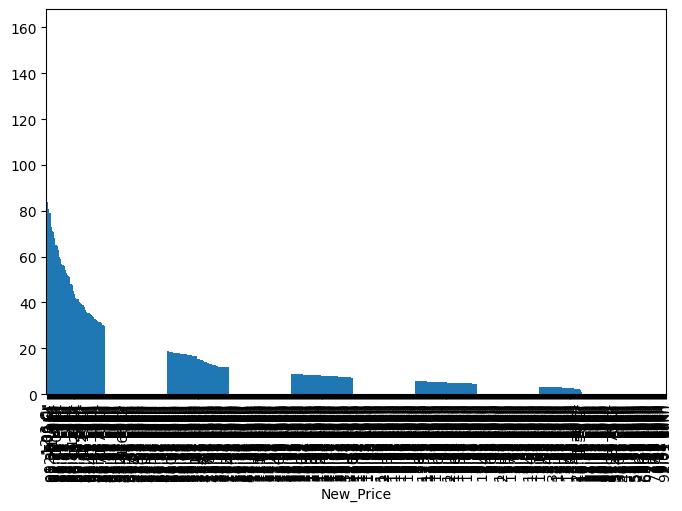

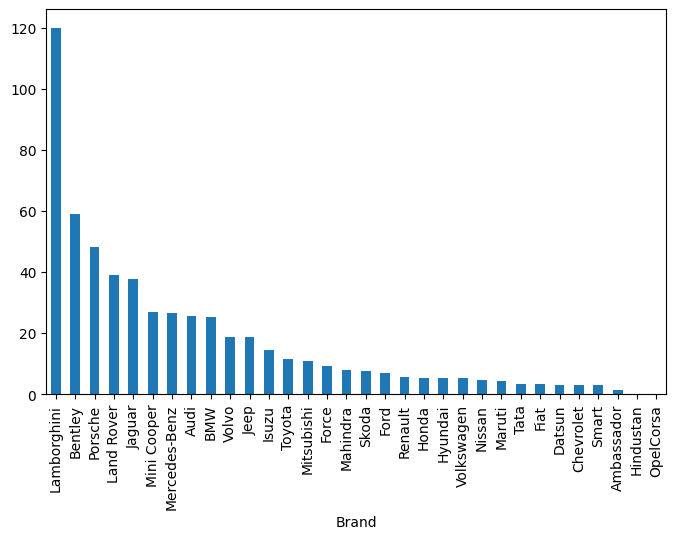

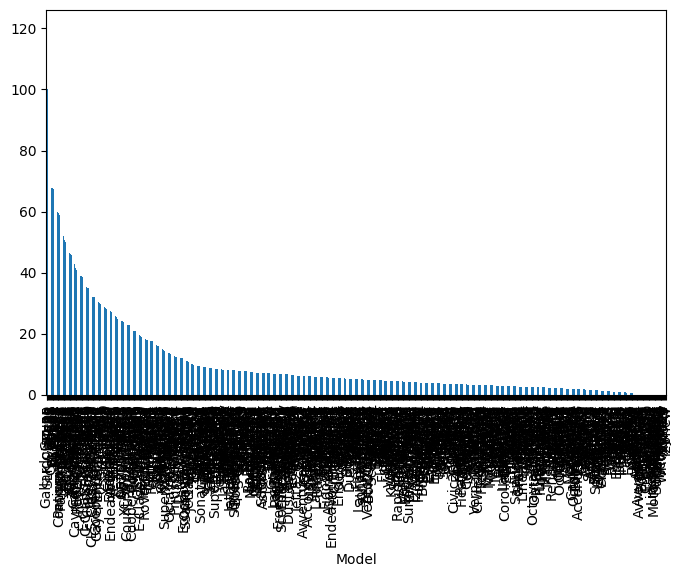

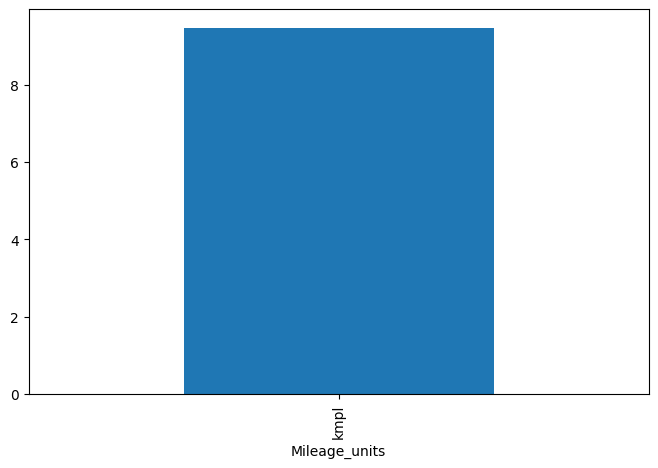

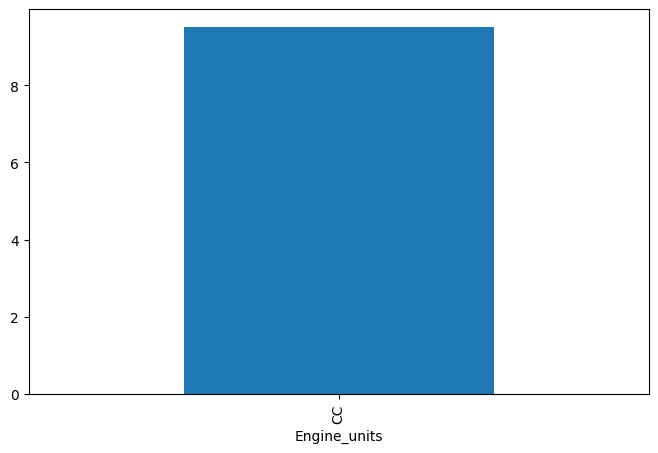

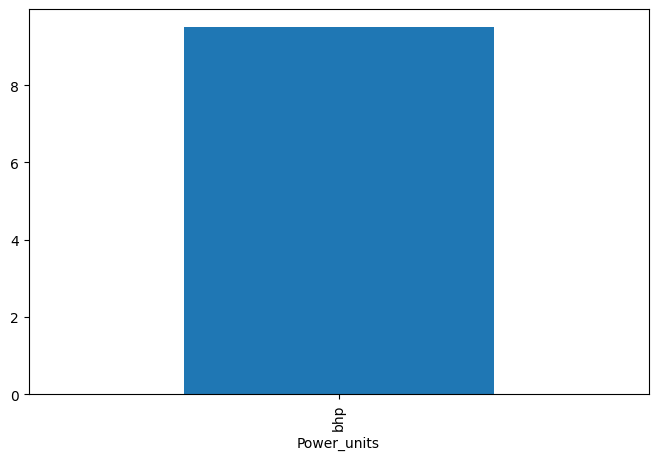

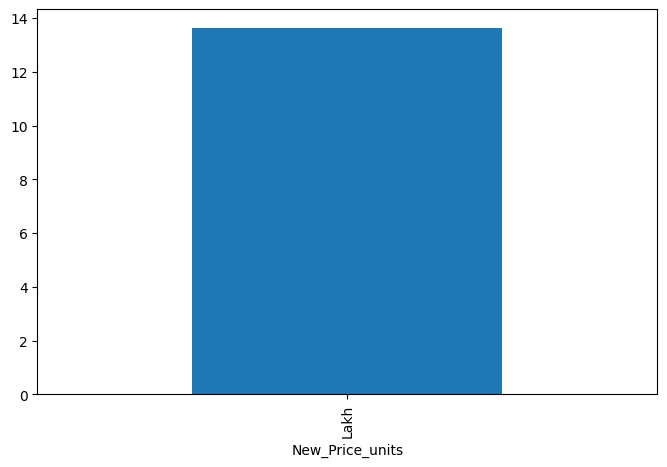

In [68]:
# Добавьте к списку категориальных столбцов Seats и Car_Age
# Постройте столбчатые диаграммы для анализа влияния категориальных переменных на цену автомобиля
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    df_cars.groupby(col)['Price'].mean().sort_values(ascending = False).plot(kind = 'bar')
    plt.show()


###### <b><font color='saddlebrown'>3.3. Многомерный анализ</font></b>
Многомерный анализ исследует более двух переменных для определения взаимосвязей между ними и анализа закономерностей. Чаще всего для этих целей используется тепловая карта, показывающая корреляцию между переменными.

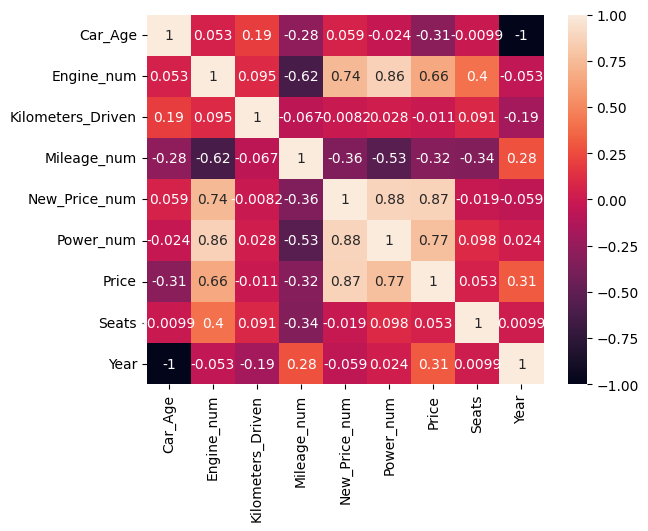

In [69]:
# Постройте тепловую карту для числовых переменных
plt.figure()
sns.heatmap(df_cars[num_cols].corr(), annot = True)
plt.show()

##### <b><font color='saddlebrown'>Сохранение результатов</font></b>
- пиклинг (pickling) запись данных в файл
- анпиклинг (unpickling) восстановление датафрейма из файла

In [ ]:
# df_cars.to_pickle('../data/df_cars_1.pkl')

In [79]:
google_free = pd.read_pickle('../data/df_google.pkl')
google_free

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Size_Measure,Date_new
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.000000,"10,000+",Free,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,M,2018-01-07
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.000000,"500,000+",Free,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,M,2018-01-15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.700000,"5,000,000+",Free,0.0,Everyone,Art & Design,1.2.4,4.0.3 and up,M,2018-08-01
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.000000,"50,000,000+",Free,0.0,Teen,Art & Design,Varies with device,4.2 and up,M,2018-06-08
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.800000,"100,000+",Free,0.0,Everyone,Art & Design;Creativity,1.1,4.4 and up,M,2018-06-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.000000,"5,000+",Free,0.0,Everyone,Education,1.48,4.1 and up,M,2017-07-25
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.600000,100+,Free,0.0,Everyone,Education,1.0,4.1 and up,M,2018-07-06
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.500000,"1,000+",Free,0.0,Everyone,Medical,1.0,2.2 and up,M,2017-01-20
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,13.310188,"1,000+",Free,0.0,Mature 17+,Books & Reference,Varies with device,Varies with device,k,2015-01-19


,Category,counts
11,FAMILY,1755
14,GAME,1038
29,TOOLS,765
4,BUSINESS,415
25,PRODUCTIVITY,379
18,LIFESTYLE,354
12,FINANCE,343
6,COMMUNICATION,339
28,SPORTS,327
20,MEDICAL,324


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_10648\2595775168.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Category', y = 'counts', data = google_free_cat, palette = 'viridis', orient = 'h')


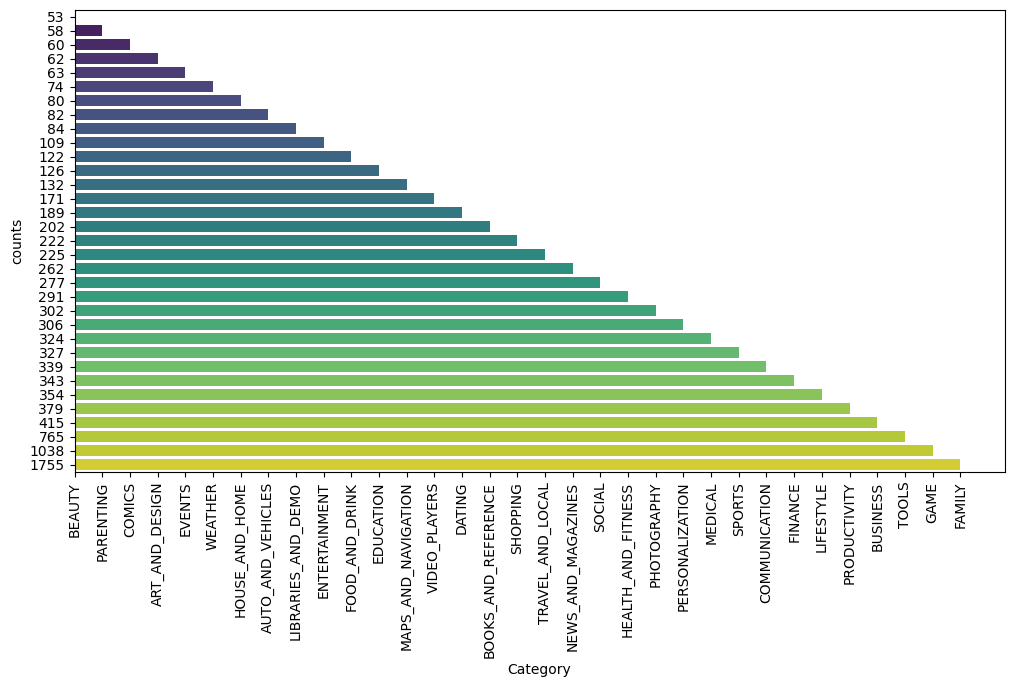

In [89]:
# Одномерный анализ категориальных столбцов
google_free_cat = google_free.groupby('Category').size().reset_index(name='counts').sort_values('counts', ascending = False)
display(google_free_cat)
plt.figure(figsize=(12, 6))
sns.barplot(x = 'Category', y = 'counts', data = google_free_cat, palette = 'viridis', orient = 'h')
plt.xticks(rotation = 90)
plt.show()